In [1]:
import torch            # PyTorch 핵심 라이브러리
import torch.nn as nn   # 신경망 레이어 정의
import torch.nn.functional as F # 신경망 함수 (ReLU, Loss 등)
import torch.optim as optim # 옵티마이저 (학습 알고리즘)
from torch.utils.data import DataLoader # 배치 데이터 로드
from torchvision import datasets, transforms # 이미지 데이터셋 및 전처리


import matplotlib.pyplot as plt # 데이터 시각화
import numpy as np              # 수치 계산 및 배열 처리

np.random.seed(123)
torch.manual_seed(123)

In [ ]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        self.cn1 = nn.Conv2d(1,16,3,1)
        self.cn2 = nn.Conv2d(16,32,3,1)
        self.dp1 = nn.Dropout2d(0.10)
        self.dp2 = nn.Dropout2d(0.25)
        self.fc1 = nn.Linear(4608,64)
        self.fc2 = nn.Linear(64,10)


    def forward(self,x):
        x = self.cn1(x)
        x = F.relu(x)
        
        x = self.cn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x,2)
        x = self.dp1(x)

        x = torch.flatten(x,1) # 배치 제외하고 평탄화

        x = self.fc1(x)
        x = self.dp2(x)
        x = self.fc2(x)
        x = F.log_softmax(x,dim=1) # (b,c)
        return x

In [11]:
a = torch.tensor([[1,2,3,4,5],[6,7,8,9,10]]).to(torch.float32)
F.log_softmax(a,dim=1)
F.log_softmax(a,dim=0)

tensor([[-5.0067, -5.0067, -5.0067, -5.0067, -5.0067],
        [-0.0067, -0.0067, -0.0067, -0.0067, -0.0067]])

In [ ]:
a = torch.tensor([[
    [[1,2,3,4,5],
     [6,7,8,9,10]],
    
    [[1,2,3,4,5],
     [6,7,8,9,10]],
    
    [[1,2,3,4,5],
     [6,7,8,9,10]],
    ]])
torch.flatten(a,1)

tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10,  1,  2,  3,  4,  5,  6,  7,  8,
          9, 10,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]])

In [23]:
def train(model, device, train_loader, optim, epoch):
    model.train()
    model.to(device)

    for b_i, (X,y) in enumerate(train_loader):
        X,y = X.to(device),y.to(device)

        optim.zero_grad()
        pred_prob = model(X)
        loss = F.nll_loss(pred_prob, y)
        loss.backward()
        optim.step()

        if b_i % 10 == 0:
            print('epoch: {} [{}/{} ({:.0f}%)]\t training loss: {:.6f}'.format(
                epoch, b_i * len(X), len(train_loader.dataset),
                100. * b_i / len(train_loader), loss.item()
            ))

In [24]:
def test(model, device, test_loader):
    model.eval()
    loss = 0
    success = 0
    model.to(device)

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device),y.to(device)

            pred_prob = model(X)

            loss += F.nll_loss(pred_prob, y, reduction='sum').item()

            pred = pred_prob.argmax(dim=1,keepdim=True)

            success += pred.eq(y.view_as(pred)).sum().item()
    
    loss /= len(test_loader.dataset)

    print('Test dataset: Overall Loss: {:.4f}, Overall Accuracy: {}/{} ({:.0}%)\n'.format(
        loss, success, len(test_loader.dataset),
        100.*success / len(test_loader.dataset)
    ))

In [18]:
a = torch.tensor([[1,2,3,4,5],[6,7,8,9,10]]).to(torch.float32)
a.argmax(dim=1,keepdim=True)

tensor([[4],
        [4]])

In [20]:
train_dataloader = DataLoader(
    datasets.MNIST('../data',train=True,download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1302),(0.3069))
                   ])),
                   batch_size=32,
                   shuffle=True
)

test_dataloader = DataLoader(
    datasets.MNIST('../data',train=False,download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1302),(0.3069))
                   ])),
                   batch_size=500,
                   shuffle=False
)

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ConvNet()
optimizer = optim.Adadelta(model.parameters(),lr=0.5)

In [28]:
for epoch in range(1,2):
    train(model,device,train_dataloader,optimizer,epoch)
test(model,device,test_dataloader)

/home/kim/miniconda3/envs/ai_env/lib/python3.12/site-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


epoch: 1 [0/60000 (0%)]	 training loss: 0.054724
epoch: 1 [320/60000 (1%)]	 training loss: 0.009117
epoch: 1 [640/60000 (1%)]	 training loss: 0.236988
epoch: 1 [960/60000 (2%)]	 training loss: 0.067052
epoch: 1 [1280/60000 (2%)]	 training loss: 0.011991
epoch: 1 [1600/60000 (3%)]	 training loss: 0.042460
epoch: 1 [1920/60000 (3%)]	 training loss: 0.085899
epoch: 1 [2240/60000 (4%)]	 training loss: 0.053404
epoch: 1 [2560/60000 (4%)]	 training loss: 0.016811
epoch: 1 [2880/60000 (5%)]	 training loss: 0.231003
epoch: 1 [3200/60000 (5%)]	 training loss: 0.075361
epoch: 1 [3520/60000 (6%)]	 training loss: 0.009931
epoch: 1 [3840/60000 (6%)]	 training loss: 0.025664
epoch: 1 [4160/60000 (7%)]	 training loss: 0.122225
epoch: 1 [4480/60000 (7%)]	 training loss: 0.068568
epoch: 1 [4800/60000 (8%)]	 training loss: 0.010521
epoch: 1 [5120/60000 (9%)]	 training loss: 0.123691
epoch: 1 [5440/60000 (9%)]	 training loss: 0.006166
epoch: 1 [5760/60000 (10%)]	 training loss: 0.001408
epoch: 1 [6080/60

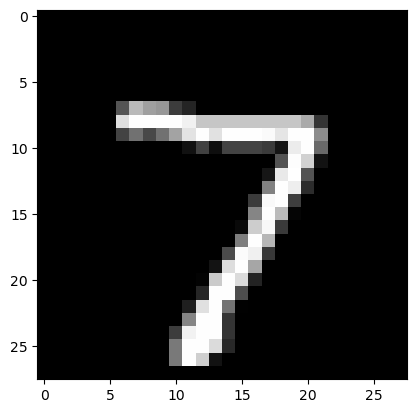

In [32]:
test_samples = enumerate(test_dataloader)
b_i, (sample_data, sample_targets) = next(test_samples)

plt.imshow(sample_data[0][0],cmap='gray', interpolation='none')
plt.show()


In [40]:
sample_data.shape

torch.Size([500, 1, 28, 28])

In [38]:
sample_data.device

device(type='cpu')

In [41]:
print(f'Model prediction: {model(sample_data.to(device)).data.max(1)[1][0]}')
print(f'Ground truth: {sample_targets[0]}')

Model prediction: 7
Ground truth: 7


/home/kim/miniconda3/envs/ai_env/lib/python3.12/site-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


visualize filters

In [43]:
model_children_list = list(model.children())
model_children_list

[Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1)),
 Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1)),
 Dropout2d(p=0.1, inplace=False),
 Dropout2d(p=0.25, inplace=False),
 Linear(in_features=4608, out_features=64, bias=True),
 Linear(in_features=64, out_features=10, bias=True)]

In [46]:
convolution_layers = []
model_parameters = []

In [47]:
convolution_layers = []
model_parameters = []
for i in range(len(model_children_list)):
    if type(model_children_list[i]) == nn.Conv2d:
        model_parameters.append(model_children_list[i].weight)
        convolution_layers.append(model_children_list[i])

In [52]:
model_parameters[0].shape

torch.Size([16, 1, 3, 3])

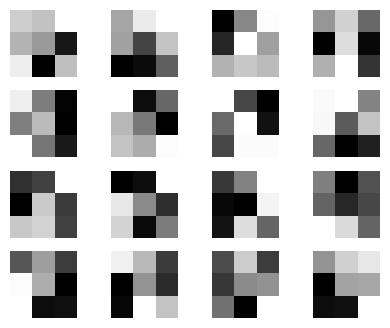

In [ ]:
plt.figure(figsize=(5,4))
for i, flt in enumerate(model_parameters[0]):
    plt.subplot(4,4,i+1)
    plt.imshow(flt[0,:,:].detach().cpu(),cmap='gray')
    plt.axis('off')

plt.show() # 필터 모양 확인 가능

In [54]:
model_parameters[1].shape

torch.Size([32, 16, 3, 3])

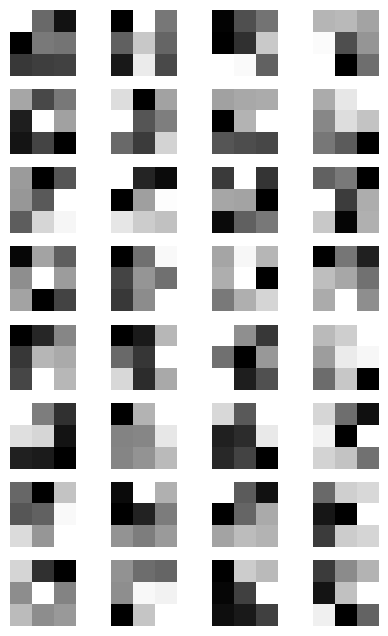

In [53]:
plt.figure(figsize=(5,8))
for i, flt in enumerate(model_parameters[1]):
    plt.subplot(8,4,i+1)
    plt.imshow(flt[0,:,:].detach().cpu(),cmap='gray')
    plt.axis('off')

plt.show() # 필터 모양 확인 가능

In [58]:
convolution_layers

[Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1)),
 Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))]

In [59]:
per_layer_results = [convolution_layers[0](sample_data.to(device))]

for i in range(1,len(convolution_layers)):
    next_input = per_layer_results[-1]
    per_layer_results.append(convolution_layers[i](next_input))

torch.Size([16, 26, 26])


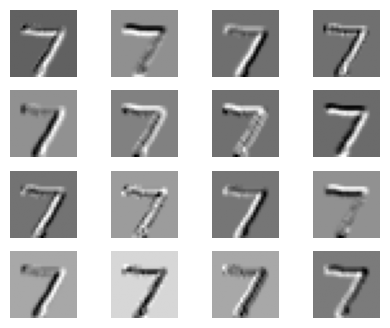

In [71]:
plt.figure(figsize=(5,4))

layer_visualisation = per_layer_results[0][0,:,:,:]
layer_visualisation = layer_visualisation.data
print(layer_visualisation.size())

for i, flt in enumerate(layer_visualisation):
    plt.subplot(4,4,i+1)
    plt.imshow(flt.cpu(),cmap='gray')
    plt.axis('off')
plt.show()

In [66]:
per_layer_results[0][0].shape

torch.Size([16, 26, 26])

torch.Size([32, 24, 24])


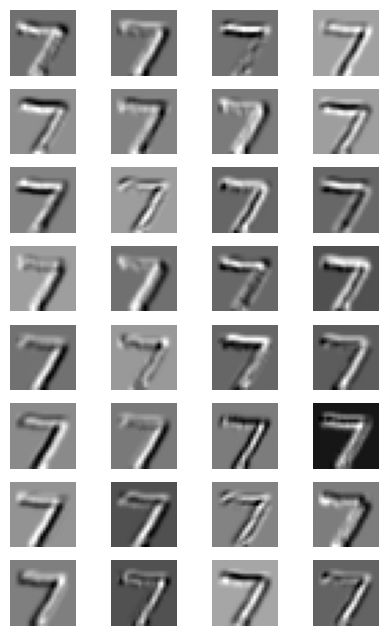

In [72]:
plt.figure(figsize=(5,8))

layer_visualisation = per_layer_results[1][0,:,:,:]
layer_visualisation = layer_visualisation.data
print(layer_visualisation.size())

for i, flt in enumerate(layer_visualisation):
    plt.subplot(8,4,i+1)
    plt.imshow(flt.cpu(),cmap='gray')
    plt.axis('off')
plt.show()